In [1]:

# Start by understanding the available data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import linregress
import os

# List all available files
print("Available files:")
for f in sorted(os.listdir('.')):
 if f.endswith(('.npy', '.npz', '.csv', '.parquet')):
 print(f" {f}")


Available files:
 N_max.npy
 a_f_alt.npy
 a_f_fully_rand.npy
 a_f_rand.npy
 a_zeta.npy


In [2]:

# Load the coefficient data
a_zeta = np.load('a_zeta.npy')
a_f_rand = np.load('a_f_rand.npy')
a_f_alt = np.load('a_f_alt.npy')
a_f_fully_rand = np.load('a_f_fully_rand.npy')
N_max = np.load('N_max.npy')

print(f"N_max: {N_max}")
print(f"a_zeta shape: {a_zeta.shape}")
print(f"a_f_rand shape: {a_f_rand.shape}")
print(f"a_f_alt shape: {a_f_alt.shape}")
print(f"a_f_fully_rand shape: {a_f_fully_rand.shape}")
print()
print("First 20 coefficients:")
print(f"a_zeta: {a_zeta[:20]}")
print(f"a_f_rand: {a_f_rand[:20]}")
print(f"a_f_fully_rand: {a_f_fully_rand[:20]}")


N_max: 100000
a_zeta shape: (100001,)
a_f_rand shape: (100001,)
a_f_alt shape: (100001,)
a_f_fully_rand shape: (100001,)

First 20 coefficients:
a_zeta: [0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
a_f_rand: [ 0. 1. -1. 1. 1. -1. -1. -1. -1. 1. 1. -1. 1. 1. 1. -1. 1. -1.
 -1. -1.]
a_f_fully_rand: [ 0. -1. 1. -1. 0. -1. -1. 1. 0. 0. -1. -1. 0. -1. 1. -1. 0. -1.
 0. -1.]


In [3]:

# Analysis Plan:
# 1. Implement function to compute D_F(t; N) = Σ_{n≤N} a_n(F) / n^(1/2 + it)
# 2. Implement function to compute R_comp metric (mean resultant length of composite squarefree terms)
# 3. For f_rand and f_fully_rand, scan t in [1000, 2000] at N=10^5 to find highest peak
# 4. At the selected t for each function, compute R_comp for N = 10^4, 5*10^4, 10^5, 5*10^5, 10^6
# 5. Fit power-law model R_comp(N) = c * N^α
# 6. Report α and R² values, compare to ζ (α ≈ 0) and L_DH (α ≈ -0.53)

# First, let's implement the necessary functions
def is_squarefree(n):
 """Check if n is squarefree"""
 if n <= 1:
 return False
 i = 2
 while i * i <= n:
 if n % (i * i) == 0:
 return False
 i += 1
 return True

def omega(n):
 """Count number of distinct prime factors"""
 if n <= 1:
 return 0
 count = 0
 i = 2
 while i * i <= n:
 if n % i == 0:
 count += 1
 while n % i == 0:
 n //= i
 i += 1
 if n > 1:
 count += 1
 return count

# Precompute squarefree flags and omega values up to N_max
print("Precomputing squarefree flags and omega values...")
squarefree_flags = np.array([is_squarefree(n) for n in range(N_max + 1)])
omega_values = np.array([omega(n) for n in range(N_max + 1)])

print(f"Number of squarefree integers up to {N_max}: {np.sum(squarefree_flags)}")
print(f"First 20 squarefree flags: {squarefree_flags[:20]}")
print(f"First 20 omega values: {omega_values[:20]}")


Precomputing squarefree flags and omega values...


Number of squarefree integers up to 100000: 60793
First 20 squarefree flags: [False False True True False True True True False False True True
 False True True True False True False True]
First 20 omega values: [0 0 1 1 1 1 2 1 1 1 2 1 2 1 2 2 1 1 2 1]


In [4]:

def compute_D_F(a_n, t, N):
 """
 Compute D_F(t; N) = Σ_{n≤N} a_n / n^(1/2 + it)
 Using Kahan compensated summation for numerical precision
 """
 result = 0.0 + 0.0j
 c = 0.0 + 0.0j # Compensation for lost low-order bits
 
 for n in range(1, min(N + 1, len(a_n))):
 if a_n[n] == 0:
 continue
 # n^(1/2 + it) = n^0.5 * n^(it) = sqrt(n) * exp(it * log(n))
 term = a_n[n] / (np.sqrt(n) * np.exp(1j * t * np.log(n)))
 
 # Kahan summation
 y = term - c
 temp = result + y
 c = (temp - result) - y
 result = temp
 
 return result

# Test the function
t_test = 1000.0
N_test = 1000
D_zeta = compute_D_F(a_zeta, t_test, N_test)
print(f"Test D_zeta(t={t_test}, N={N_test}): {D_zeta}")
print(f"Magnitude: {np.abs(D_zeta):.6f}")


Test D_zeta(t=1000.0, N=1000): (0.3598436407578809+0.8991983230436902j)
Magnitude: 0.968527


In [5]:

def compute_R_comp(a_n, t, N):
 """
 Compute R_comp: mean resultant length of composite squarefree terms.
 
 R_comp measures the phase coherence of composite (ω(n) ≥ 2) squarefree terms.
 
 R_comp = |Σ_{n: squarefree, ω(n)≥2} exp(-it*log(n))| / Count_{n: squarefree, ω(n)≥2}
 """
 sum_vectors = 0.0 + 0.0j
 count = 0
 
 for n in range(1, min(N + 1, len(a_n))):
 # Only include squarefree composite numbers
 if n >= len(squarefree_flags) or n >= len(omega_values):
 continue
 if squarefree_flags[n] and omega_values[n] >= 2:
 # The phase factor from n^(1/2 + it) = sqrt(n) * exp(it * log(n))
 # We track exp(-it * log(n)) as the unit vector
 sum_vectors += np.exp(-1j * t * np.log(n))
 count += 1
 
 if count == 0:
 return 0.0
 
 # Mean resultant length
 R_comp = np.abs(sum_vectors) / count
 return R_comp

# Test the function
R_comp_zeta = compute_R_comp(a_zeta, t_test, N_test)
print(f"Test R_comp for zeta (t={t_test}, N={N_test}): {R_comp_zeta:.6f}")

R_comp_f_rand = compute_R_comp(a_f_rand, t_test, N_test)
print(f"Test R_comp for f_rand (t={t_test}, N={N_test}): {R_comp_f_rand:.6f}")

R_comp_f_fully_rand = compute_R_comp(a_f_fully_rand, t_test, N_test)
print(f"Test R_comp for f_fully_rand (t={t_test}, N={N_test}): {R_comp_f_fully_rand:.6f}")


Test R_comp for zeta (t=1000.0, N=1000): 0.024978
Test R_comp for f_rand (t=1000.0, N=1000): 0.024978
Test R_comp for f_fully_rand (t=1000.0, N=1000): 0.024978


In [6]:

# Now scan t in [1000, 2000] at N=10^5 to find highest peaks for f_rand and f_fully_rand
# Use a coarse sampling first to find approximate peak locations

N_scan = 100000
t_min, t_max = 1000, 2000
dt = 1.0 # Sample every 1 unit

t_values = np.arange(t_min, t_max + dt, dt)
print(f"Scanning t from {t_min} to {t_max} with dt={dt} at N={N_scan}")
print(f"Number of t points: {len(t_values)}")

# Compute magnitudes for f_rand
print("\nComputing magnitudes for f_rand...")
mags_f_rand = []
for i, t in enumerate(t_values):
 if i % 100 == 0:
 print(f" Progress: {i}/{len(t_values)}")
 D = compute_D_F(a_f_rand, t, N_scan)
 mags_f_rand.append(np.abs(D))

mags_f_rand = np.array(mags_f_rand)
idx_max_f_rand = np.argmax(mags_f_rand)
t_peak_f_rand = t_values[idx_max_f_rand]
mag_peak_f_rand = mags_f_rand[idx_max_f_rand]

print(f"\nf_rand peak: t = {t_peak_f_rand:.2f}, magnitude = {mag_peak_f_rand:.6f}")


Scanning t from 1000 to 2000 with dt=1.0 at N=100000
Number of t points: 1001

Computing magnitudes for f_rand...
 Progress: 0/1001


 Progress: 100/1001


 Progress: 200/1001


 Progress: 300/1001


 Progress: 400/1001


...

 Progress: 700/1001


 Progress: 800/1001


 Progress: 900/1001


 Progress: 1000/1001



f_rand peak: t = 1962.00, magnitude = 29.426316


In [7]:

# Compute magnitudes for f_fully_rand
print("Computing magnitudes for f_fully_rand...")
mags_f_fully_rand = []
for i, t in enumerate(t_values):
 if i % 100 == 0:
 print(f" Progress: {i}/{len(t_values)}")
 D = compute_D_F(a_f_fully_rand, t, N_scan)
 mags_f_fully_rand.append(np.abs(D))

mags_f_fully_rand = np.array(mags_f_fully_rand)
idx_max_f_fully_rand = np.argmax(mags_f_fully_rand)
t_peak_f_fully_rand = t_values[idx_max_f_fully_rand]
mag_peak_f_fully_rand = mags_f_fully_rand[idx_max_f_fully_rand]

print(f"\nf_fully_rand peak: t = {t_peak_f_fully_rand:.2f}, magnitude = {mag_peak_f_fully_rand:.6f}")


Computing magnitudes for f_fully_rand...
 Progress: 0/1001


 Progress: 100/1001


 Progress: 200/1001


 Progress: 300/1001


 Progress: 400/1001


...

 Progress: 700/1001


 Progress: 800/1001


 Progress: 900/1001


 Progress: 1000/1001



f_fully_rand peak: t = 1882.00, magnitude = 8.159770


In [8]:

# Now compute R_comp at these peak t values for different N values
N_values = np.array([10000, 50000, 100000, 500000, 1000000])

print("=" * 70)
print("Computing R_comp scaling for f_rand")
print("=" * 70)
print(f"Peak t value: {t_peak_f_rand:.2f}")
print(f"N values: {N_values}")
print()

R_comp_f_rand_scaling = []
for N in N_values:
 print(f"Computing R_comp for N = {N}...")
 R = compute_R_comp(a_f_rand, t_peak_f_rand, N)
 R_comp_f_rand_scaling.append(R)
 print(f" R_comp = {R:.8f}")

R_comp_f_rand_scaling = np.array(R_comp_f_rand_scaling)
print()
print(f"R_comp values for f_rand: {R_comp_f_rand_scaling}")


Computing R_comp scaling for f_rand
Peak t value: 1962.00
N values: [ 10000 50000 100000 500000 1000000]

Computing R_comp for N = 10000...
 R_comp = 0.00945185
Computing R_comp for N = 50000...
 R_comp = 0.00120522
Computing R_comp for N = 100000...
 R_comp = 0.00057989
Computing R_comp for N = 500000...


 R_comp = 0.00057989
Computing R_comp for N = 1000000...
 R_comp = 0.00057989

R_comp values for f_rand: [0.00945185 0.00120522 0.00057989 0.00057989 0.00057989]


In [9]:

# There's an issue - for N > 100000, we only have coefficients up to 100000
# So we need to handle this properly
print(f"Length of a_f_rand: {len(a_f_rand)}")
print(f"Maximum N we can use: {len(a_f_rand) - 1}")
print("\nNote: We cannot compute for N > 100000 with the available coefficient data.")
print("Adjusting N values to stay within available data...")

# Use only N values that are within our data range
N_values = np.array([10000, 25000, 50000, 75000, 100000])

print(f"\nAdjusted N values: {N_values}")


Length of a_f_rand: 100001
Maximum N we can use: 100000

Note: We cannot compute for N > 100000 with the available coefficient data.
Adjusting N values to stay within available data...

Adjusted N values: [ 10000 25000 50000 75000 100000]


In [10]:

# Recompute R_comp scaling for f_rand with adjusted N values
print("=" * 70)
print("Computing R_comp scaling for f_rand (adjusted N range)")
print("=" * 70)
print(f"Peak t value: {t_peak_f_rand:.2f}")
print(f"N values: {N_values}")
print()

R_comp_f_rand_scaling = []
for N in N_values:
 print(f"Computing R_comp for N = {N}...")
 R = compute_R_comp(a_f_rand, t_peak_f_rand, N)
 R_comp_f_rand_scaling.append(R)
 print(f" R_comp = {R:.8f}")

R_comp_f_rand_scaling = np.array(R_comp_f_rand_scaling)
print()
print("Summary for f_rand:")
print(f"N values: {N_values}")
print(f"R_comp values: {R_comp_f_rand_scaling}")


Computing R_comp scaling for f_rand (adjusted N range)
Peak t value: 1962.00
N values: [ 10000 25000 50000 75000 100000]

Computing R_comp for N = 10000...
 R_comp = 0.00945185
Computing R_comp for N = 25000...
 R_comp = 0.00722062
Computing R_comp for N = 50000...
 R_comp = 0.00120522
Computing R_comp for N = 75000...
 R_comp = 0.00079034
Computing R_comp for N = 100000...


 R_comp = 0.00057989

Summary for f_rand:
N values: [ 10000 25000 50000 75000 100000]
R_comp values: [0.00945185 0.00722062 0.00120522 0.00079034 0.00057989]


In [11]:

# Compute R_comp scaling for f_fully_rand
print("=" * 70)
print("Computing R_comp scaling for f_fully_rand")
print("=" * 70)
print(f"Peak t value: {t_peak_f_fully_rand:.2f}")
print(f"N values: {N_values}")
print()

R_comp_f_fully_rand_scaling = []
for N in N_values:
 print(f"Computing R_comp for N = {N}...")
 R = compute_R_comp(a_f_fully_rand, t_peak_f_fully_rand, N)
 R_comp_f_fully_rand_scaling.append(R)
 print(f" R_comp = {R:.8f}")

R_comp_f_fully_rand_scaling = np.array(R_comp_f_fully_rand_scaling)
print()
print("Summary for f_fully_rand:")
print(f"N values: {N_values}")
print(f"R_comp values: {R_comp_f_fully_rand_scaling}")


Computing R_comp scaling for f_fully_rand
Peak t value: 1882.00
N values: [ 10000 25000 50000 75000 100000]

Computing R_comp for N = 10000...
 R_comp = 0.00706261
Computing R_comp for N = 25000...
 R_comp = 0.00345526
Computing R_comp for N = 50000...
 R_comp = 0.00219175
Computing R_comp for N = 75000...
 R_comp = 0.00045620
Computing R_comp for N = 100000...


 R_comp = 0.00154180

Summary for f_fully_rand:
N values: [ 10000 25000 50000 75000 100000]
R_comp values: [0.00706261 0.00345526 0.00219175 0.0004562 0.0015418 ]


In [12]:

# Fit power-law model: R_comp(N) = c * N^α
# Taking log: log(R_comp) = log(c) + α * log(N)

def power_law(N, c, alpha):
 return c * N**alpha

def fit_power_law(N_data, R_data):
 """
 Fit R_comp(N) = c * N^α using linear regression on log-log scale
 Returns: alpha, c, R², and standard error of alpha
 """
 log_N = np.log10(N_data)
 log_R = np.log10(R_data)
 
 # Linear regression on log-log scale
 slope, intercept, r_value, p_value, std_err = linregress(log_N, log_R)
 
 alpha = slope
 c = 10**intercept
 r_squared = r_value**2
 
 return alpha, c, r_squared, std_err

# Fit for f_rand
alpha_f_rand, c_f_rand, r2_f_rand, stderr_f_rand = fit_power_law(N_values, R_comp_f_rand_scaling)

print("=" * 70)
print("Power-law fit for f_rand: R_comp(N) = c * N^α")
print("=" * 70)
print(f"Exponent α = {alpha_f_rand:.4f} ± {stderr_f_rand:.4f}")
print(f"Coefficient c = {c_f_rand:.6e}")
print(f"R² = {r2_f_rand:.6f}")
print()

# Fit for f_fully_rand
alpha_f_fully_rand, c_f_fully_rand, r2_f_fully_rand, stderr_f_fully_rand = fit_power_law(
 N_values, R_comp_f_fully_rand_scaling
)

print("=" * 70)
print("Power-law fit for f_fully_rand: R_comp(N) = c * N^α")
print("=" * 70)
print(f"Exponent α = {alpha_f_fully_rand:.4f} ± {stderr_f_fully_rand:.4f}")
print(f"Coefficient c = {c_f_fully_rand:.6e}")
print(f"R² = {r2_f_fully_rand:.6f}")


Power-law fit for f_rand: R_comp(N) = c * N^α
Exponent α = -1.3383 ± 0.2356
Coefficient c = 2.910010e+03
R² = 0.914913

Power-law fit for f_fully_rand: R_comp(N) = c * N^α
Exponent α = -0.9196 ± 0.3486
Coefficient c = 3.467590e+01
R² = 0.698719


In [13]:

# The results show power-law decay for both functions, which is unexpected for f_rand
# Let me verify the R_comp calculation - I need to check if I'm computing it correctly
# According to the description, R_comp should be independent of coefficients a_n
# and only depend on the phase coherence of the composite squarefree numbers

# Let me recalculate and verify
print("Verification: R_comp should be independent of a_n values")
print("It only depends on phase coherence of composite squarefree terms")
print()

# Let's test at a different t value to see if there's t-dependence
t_test_2 = 1500.0
N_test_2 = 50000

print(f"Testing at t = {t_test_2}, N = {N_test_2}")
R_zeta_test = compute_R_comp(a_zeta, t_test_2, N_test_2)
R_f_rand_test = compute_R_comp(a_f_rand, t_test_2, N_test_2)
R_f_fully_rand_test = compute_R_comp(a_f_fully_rand, t_test_2, N_test_2)

print(f"R_comp(zeta): {R_zeta_test:.8f}")
print(f"R_comp(f_rand): {R_f_rand_test:.8f}")
print(f"R_comp(f_fully_rand): {R_f_fully_rand_test:.8f}")
print()
print("Notice: All three have the same R_comp!")
print("This confirms that R_comp is independent of the specific coefficient values.")


Verification: R_comp should be independent of a_n values
It only depends on phase coherence of composite squarefree terms

Testing at t = 1500.0, N = 50000
R_comp(zeta): 0.00245925
R_comp(f_rand): 0.00245925
R_comp(f_fully_rand): 0.00245925

Notice: All three have the same R_comp!
This confirms that R_comp is independent of the specific coefficient values.


In [14]:

# I see the issue now! R_comp is computed ONLY based on phase factors exp(-it*log(n))
# and doesn't depend on a_n at all in my implementation.
# 
# Let me re-read the description more carefully. The description says:
# "The mean resultant length of composite squarefree terms (R_comp) is sensitive to 
# both multiplicativity and coefficient patterns."
#
# Looking at the M_coh definition: |ΣS_k| / √Σ|S_k|² where S_k are sums partitioned by ω(n)
# And for R_comp, it measures phase coherence - but should it weight by coefficients?
#
# Let me check if R_comp should include the a_n coefficients in the sum

def compute_R_comp_v2(a_n, t, N):
 """
 Compute R_comp: mean resultant length of composite squarefree terms.
 
 This version includes the coefficient a_n in the sum.
 
 R_comp = |Σ_{n: squarefree, ω(n)≥2} a_n * exp(-it*log(n))| / Count_{n: squarefree, ω(n)≥2, a_n≠0}
 """
 sum_vectors = 0.0 + 0.0j
 count = 0
 
 for n in range(1, min(N + 1, len(a_n))):
 if a_n[n] == 0:
 continue
 # Only include squarefree composite numbers
 if n >= len(squarefree_flags) or n >= len(omega_values):
 continue
 if squarefree_flags[n] and omega_values[n] >= 2:
 # Include the coefficient and the phase factor
 sum_vectors += a_n[n] * np.exp(-1j * t * np.log(n))
 count += 1
 
 if count == 0:
 return 0.0
 
 # Mean resultant length
 R_comp = np.abs(sum_vectors) / count
 return R_comp

# Test the updated function
print("Testing updated R_comp calculation (v2) that includes a_n:")
print()
R_zeta_test2 = compute_R_comp_v2(a_zeta, t_test_2, N_test_2)
R_f_rand_test2 = compute_R_comp_v2(a_f_rand, t_test_2, N_test_2)
R_f_fully_rand_test2 = compute_R_comp_v2(a_f_fully_rand, t_test_2, N_test_2)

print(f"R_comp(zeta): {R_zeta_test2:.8f}")
print(f"R_comp(f_rand): {R_f_rand_test2:.8f}")
print(f"R_comp(f_fully_rand): {R_f_fully_rand_test2:.8f}")
print()
print("Now they are different! This version is coefficient-dependent.")


Testing updated R_comp calculation (v2) that includes a_n:

R_comp(zeta): 0.00245925
R_comp(f_rand): 0.00450016
R_comp(f_fully_rand): 0.00418098

Now they are different! This version is coefficient-dependent.


In [15]:

# Good! Now let's recompute the scaling analysis with the corrected R_comp function
# that includes the a_n coefficients

print("=" * 70)
print("Recomputing R_comp scaling for f_rand (corrected version)")
print("=" * 70)
print(f"Peak t value: {t_peak_f_rand:.2f}")
print(f"N values: {N_values}")
print()

R_comp_f_rand_scaling_v2 = []
for N in N_values:
 print(f"Computing R_comp for N = {N}...")
 R = compute_R_comp_v2(a_f_rand, t_peak_f_rand, N)
 R_comp_f_rand_scaling_v2.append(R)
 print(f" R_comp = {R:.8f}")

R_comp_f_rand_scaling_v2 = np.array(R_comp_f_rand_scaling_v2)
print()
print("Summary for f_rand (v2):")
print(f"N values: {N_values}")
print(f"R_comp values: {R_comp_f_rand_scaling_v2}")


Recomputing R_comp scaling for f_rand (corrected version)
Peak t value: 1962.00
N values: [ 10000 25000 50000 75000 100000]

Computing R_comp for N = 10000...
 R_comp = 0.05884043
Computing R_comp for N = 25000...
 R_comp = 0.03323922
Computing R_comp for N = 50000...
 R_comp = 0.02153141
Computing R_comp for N = 75000...


 R_comp = 0.01781977
Computing R_comp for N = 100000...
 R_comp = 0.01418574

Summary for f_rand (v2):
N values: [ 10000 25000 50000 75000 100000]
R_comp values: [0.05884043 0.03323922 0.02153141 0.01781977 0.01418574]


In [16]:

print("=" * 70)
print("Recomputing R_comp scaling for f_fully_rand (corrected version)")
print("=" * 70)
print(f"Peak t value: {t_peak_f_fully_rand:.2f}")
print(f"N values: {N_values}")
print()

R_comp_f_fully_rand_scaling_v2 = []
for N in N_values:
 print(f"Computing R_comp for N = {N}...")
 R = compute_R_comp_v2(a_f_fully_rand, t_peak_f_fully_rand, N)
 R_comp_f_fully_rand_scaling_v2.append(R)
 print(f" R_comp = {R:.8f}")

R_comp_f_fully_rand_scaling_v2 = np.array(R_comp_f_fully_rand_scaling_v2)
print()
print("Summary for f_fully_rand (v2):")
print(f"N values: {N_values}")
print(f"R_comp values: {R_comp_f_fully_rand_scaling_v2}")


Recomputing R_comp scaling for f_fully_rand (corrected version)
Peak t value: 1882.00
N values: [ 10000 25000 50000 75000 100000]

Computing R_comp for N = 10000...
 R_comp = 0.04305560
Computing R_comp for N = 25000...
 R_comp = 0.01644367
Computing R_comp for N = 50000...
 R_comp = 0.01230561
Computing R_comp for N = 75000...
 R_comp = 0.00405993
Computing R_comp for N = 100000...


 R_comp = 0.00550421

Summary for f_fully_rand (v2):
N values: [ 10000 25000 50000 75000 100000]
R_comp values: [0.0430556 0.01644367 0.01230561 0.00405993 0.00550421]


In [17]:

# Fit power-law model for corrected R_comp values

# Fit for f_rand (v2)
alpha_f_rand_v2, c_f_rand_v2, r2_f_rand_v2, stderr_f_rand_v2 = fit_power_law(
 N_values, R_comp_f_rand_scaling_v2
)

print("=" * 70)
print("Power-law fit for f_rand: R_comp(N) = c * N^α")
print("=" * 70)
print(f"Exponent α = {alpha_f_rand_v2:.4f} ± {stderr_f_rand_v2:.4f}")
print(f"Coefficient c = {c_f_rand_v2:.6e}")
print(f"R² = {r2_f_rand_v2:.6f}")
print()

# Fit for f_fully_rand (v2)
alpha_f_fully_rand_v2, c_f_fully_rand_v2, r2_f_fully_rand_v2, stderr_f_fully_rand_v2 = fit_power_law(
 N_values, R_comp_f_fully_rand_scaling_v2
)

print("=" * 70)
print("Power-law fit for f_fully_rand: R_comp(N) = c * N^α")
print("=" * 70)
print(f"Exponent α = {alpha_f_fully_rand_v2:.4f} ± {stderr_f_fully_rand_v2:.4f}")
print(f"Coefficient c = {c_f_fully_rand_v2:.6e}")
print(f"R² = {r2_f_fully_rand_v2:.6f}")
print()

# Comparison with reference values
print("=" * 70)
print("COMPARISON WITH REFERENCE VALUES FROM r67")
print("=" * 70)
print(f"ζ (Riemann zeta): α ≈ 0 (constant behavior)")
print(f"L_DH: α ≈ -0.53 (power-law decay)")
print()
print(f"f_rand (multiplicative): α = {alpha_f_rand_v2:.4f} ± {stderr_f_rand_v2:.4f}")
print(f"f_fully_rand (non-mult.): α = {alpha_f_fully_rand_v2:.4f} ± {stderr_f_fully_rand_v2:.4f}")


Power-law fit for f_rand: R_comp(N) = c * N^α
Exponent α = -0.6084 ± 0.0144
Coefficient c = 1.587974e+01
R² = 0.998315

Power-law fit for f_fully_rand: R_comp(N) = c * N^α
Exponent α = -0.9672 ± 0.1701
Coefficient c = 3.173427e+02
R² = 0.915071

COMPARISON WITH REFERENCE VALUES FROM r67
ζ (Riemann zeta): α ≈ 0 (constant behavior)
L_DH: α ≈ -0.53 (power-law decay)

f_rand (multiplicative): α = -0.6084 ± 0.0144
f_fully_rand (non-mult.): α = -0.9672 ± 0.1701


In [18]:

# The results are very interesting but unexpected:
# - Both f_rand and f_fully_rand show power-law decay (α < 0)
# - f_rand: α ≈ -0.61 (similar to L_DH's α ≈ -0.53)
# - f_fully_rand: α ≈ -0.97 (even stronger decay)
# 
# This contradicts the hypothesis that multiplicative functions should show constant behavior
# Let me investigate further. Perhaps the issue is that I'm evaluating at PEAK locations,
# which might be special. Let me try evaluating at multiple t values to see if this is consistent

# Let's compute R_comp scaling at several different t values for f_rand
t_test_values = [1000, 1200, 1500, 1800, 2000]

print("=" * 70)
print("Testing R_comp scaling at multiple t values for f_rand")
print("=" * 70)

results_by_t = []
for t_val in t_test_values:
 print(f"\nTesting at t = {t_val}")
 R_values = []
 for N in N_values:
 R = compute_R_comp_v2(a_f_rand, float(t_val), N)
 R_values.append(R)
 R_values = np.array(R_values)
 
 # Fit power law
 alpha, c, r2, stderr = fit_power_law(N_values, R_values)
 results_by_t.append({
 't': t_val,
 'alpha': alpha,
 'stderr': stderr,
 'r2': r2,
 'R_values': R_values
 })
 print(f" α = {alpha:.4f} ± {stderr:.4f}, R² = {r2:.6f}")

# Summary table
print("\n" + "=" * 70)
print("SUMMARY: R_comp scaling exponents at different t values for f_rand")
print("=" * 70)
for res in results_by_t:
 print(f"t = {res['t']:4d}: α = {res['alpha']:7.4f} ± {res['stderr']:.4f}, R² = {res['r2']:.6f}")

alpha_mean = np.mean([r['alpha'] for r in results_by_t])
alpha_std = np.std([r['alpha'] for r in results_by_t])
print(f"\nMean α across all t values: {alpha_mean:.4f} ± {alpha_std:.4f}")


Testing R_comp scaling at multiple t values for f_rand

Testing at t = 1000


 α = -0.2053 ± 0.2245, R² = 0.217995

Testing at t = 1200


 α = -0.6515 ± 0.1222, R² = 0.904578

Testing at t = 1500


 α = -0.4627 ± 0.1193, R² = 0.833630

Testing at t = 1800


 α = -0.1501 ± 0.4360, R² = 0.037997

Testing at t = 2000


 α = -0.9635 ± 0.0997, R² = 0.968875

SUMMARY: R_comp scaling exponents at different t values for f_rand
t = 1000: α = -0.2053 ± 0.2245, R² = 0.217995
t = 1200: α = -0.6515 ± 0.1222, R² = 0.904578
t = 1500: α = -0.4627 ± 0.1193, R² = 0.833630
t = 1800: α = -0.1501 ± 0.4360, R² = 0.037997
t = 2000: α = -0.9635 ± 0.0997, R² = 0.968875

Mean α across all t values: -0.4866 ± 0.2992


In [19]:

# The results show high variability in α across different t values, with some having poor R² fits
# This suggests that the scaling behavior is highly t-dependent
# 
# Let me reconsider the analysis. Perhaps I should look at zeta function to verify my implementation
# According to r67, zeta should have α ≈ 0 (constant behavior)

print("=" * 70)
print("Testing R_comp scaling for ζ (Riemann zeta) - should be constant")
print("=" * 70)

# Pick a few t values
t_test_zeta = [1000, 1500, 2000]

for t_val in t_test_zeta:
 print(f"\nTesting ζ at t = {t_val}")
 R_values_zeta = []
 for N in N_values:
 R = compute_R_comp_v2(a_zeta, float(t_val), N)
 R_values_zeta.append(R)
 R_values_zeta = np.array(R_values_zeta)
 
 # Fit power law
 alpha_zeta, c_zeta, r2_zeta, stderr_zeta = fit_power_law(N_values, R_values_zeta)
 print(f" R_comp values: {R_values_zeta}")
 print(f" α = {alpha_zeta:.4f} ± {stderr_zeta:.4f}, R² = {r2_zeta:.6f}")


Testing R_comp scaling for ζ (Riemann zeta) - should be constant

Testing ζ at t = 1000


 R_comp values: [0.00566985 0.00306204 0.00284574 0.00209249 0.00052691]
 α = -0.8029 ± 0.2972, R² = 0.708635

Testing ζ at t = 1500


 R_comp values: [0.00711251 0.00602747 0.00245925 0.00292253 0.00240003]
 α = -0.5168 ± 0.1246, R² = 0.851549

Testing ζ at t = 2000


 R_comp values: [0.00421433 0.00432536 0.00252011 0.00144069 0.00136219]
 α = -0.5500 ± 0.1424, R² = 0.832617


In [20]:

# Interesting! Even for zeta, we're seeing power-law decay (α ≈ -0.5 to -0.8), not constant behavior
# This suggests there might be an issue with my R_comp implementation or interpretation
#
# Let me reconsider: perhaps the issue is that R_comp at a FIXED t value naturally decays with N
# because as N increases, we're adding more composite numbers with different phases
# 
# But according to r67, ζ should have constant R_comp scaling. Let me check if I'm misunderstanding
# the metric definition. Perhaps they're computing R_comp differently - maybe averaging over t ranges?

# Let me try a different approach: compute R_comp over a range of t values and average
def compute_R_comp_averaged(a_n, t_min, t_max, dt, N):
 """
 Compute R_comp averaged over a range of t values
 """
 t_values = np.arange(t_min, t_max, dt)
 R_values = []
 for t in t_values:
 R = compute_R_comp_v2(a_n, t, N)
 R_values.append(R)
 return np.mean(R_values)

# Test this approach
t_min, t_max = 1000, 1100
dt = 10

print("=" * 70)
print("Testing R_comp averaged over t ∈ [1000, 1100] with dt=10")
print("=" * 70)

R_zeta_avg = []
for N in N_values:
 R = compute_R_comp_averaged(a_zeta, t_min, t_max, dt, N)
 R_zeta_avg.append(R)
 print(f"N = {N:6d}: R_comp_avg = {R:.8f}")

R_zeta_avg = np.array(R_zeta_avg)

# Fit power law
alpha_zeta_avg, c_zeta_avg, r2_zeta_avg, stderr_zeta_avg = fit_power_law(N_values, R_zeta_avg)
print(f"\nFit: α = {alpha_zeta_avg:.4f} ± {stderr_zeta_avg:.4f}, R² = {r2_zeta_avg:.6f}")


Testing R_comp averaged over t ∈ [1000, 1100] with dt=10
N = 10000: R_comp_avg = 0.00717743


N = 25000: R_comp_avg = 0.00277864


N = 50000: R_comp_avg = 0.00262933


N = 75000: R_comp_avg = 0.00236388


N = 100000: R_comp_avg = 0.00168399

Fit: α = -0.5501 ± 0.1139, R² = 0.885982


In [21]:

# Still seeing decay! Let me reconsider the R_comp definition more carefully.
# 
# Looking back at the description: "The mean resultant length of composite squarefree terms (R_comp)"
# 
# Perhaps the key issue is in how I'm normalizing. Let me check if the count should be
# based on the total number of composite squarefree terms up to N, or only those with nonzero a_n
#
# Also, maybe I should weight by |a_n| or just use the sign?

# Let me look at what happens if we DON'T normalize by count, but by the sum of |a_n|
def compute_R_comp_v3(a_n, t, N):
 """
 Compute R_comp: mean resultant length of composite squarefree terms.
 
 Version 3: Normalize by sum of absolute values
 
 R_comp = |Σ_{n: squarefree, ω(n)≥2} a_n * exp(-it*log(n))| / Σ_{n: squarefree, ω(n)≥2} |a_n|
 """
 sum_vectors = 0.0 + 0.0j
 sum_abs = 0.0
 
 for n in range(1, min(N + 1, len(a_n))):
 if a_n[n] == 0:
 continue
 # Only include squarefree composite numbers
 if n >= len(squarefree_flags) or n >= len(omega_values):
 continue
 if squarefree_flags[n] and omega_values[n] >= 2:
 # Include the coefficient and the phase factor
 sum_vectors += a_n[n] * np.exp(-1j * t * np.log(n))
 sum_abs += np.abs(a_n[n])
 
 if sum_abs == 0:
 return 0.0
 
 # Mean resultant length
 R_comp = np.abs(sum_vectors) / sum_abs
 return R_comp

# For our functions, all |a_n| = 1 for nonzero terms, so this should give the same result as v2
# But let me verify

t_test_v3 = 1500.0
N_test_v3 = 50000

R_zeta_v3 = compute_R_comp_v3(a_zeta, t_test_v3, N_test_v3)
R_f_rand_v3 = compute_R_comp_v3(a_f_rand, t_test_v3, N_test_v3)
R_f_fully_rand_v3 = compute_R_comp_v3(a_f_fully_rand, t_test_v3, N_test_v3)

R_zeta_v2 = compute_R_comp_v2(a_zeta, t_test_v3, N_test_v3)
R_f_rand_v2 = compute_R_comp_v2(a_f_rand, t_test_v3, N_test_v3)
R_f_fully_rand_v2 = compute_R_comp_v2(a_f_fully_rand, t_test_v3, N_test_v3)

print("Comparing v2 (count normalization) vs v3 (sum of |a_n| normalization):")
print()
print(f"ζ: v2 = {R_zeta_v2:.8f}, v3 = {R_zeta_v3:.8f}")
print(f"f_rand: v2 = {R_f_rand_v2:.8f}, v3 = {R_f_rand_v3:.8f}")
print(f"f_fully_rand: v2 = {R_f_fully_rand_v2:.8f}, v3 = {R_f_fully_rand_v3:.8f}")
print()
print("They should be the same since all |a_n| = 1 for nonzero terms")


Comparing v2 (count normalization) vs v3 (sum of |a_n| normalization):

ζ: v2 = 0.00245925, v3 = 0.00245925
f_rand: v2 = 0.00450016, v3 = 0.00450016
f_fully_rand: v2 = 0.00418098, v3 = 0.00418098

They should be the same since all |a_n| = 1 for nonzero terms


In [22]:

# The values match, as expected. Let me think about this differently.
# 
# Perhaps the key insight is that the HYPOTHESIS is actually wrong, or needs refinement.
# The results I'm seeing suggest:
# - Both multiplicative (f_rand) and non-multiplicative (f_fully_rand) functions show power-law decay
# - f_fully_rand shows STRONGER decay (α ≈ -0.97) than f_rand (α ≈ -0.61)
# - Even ζ shows decay (α ≈ -0.5 to -0.8)
#
# Wait - maybe the issue is that in r67, they were looking at PEAK values of R_comp across t,
# not R_comp at a fixed t value as N varies?
#
# Let me reconsider: perhaps the analysis should be:
# For each N, find the MAXIMUM R_comp value across a range of t, then see how that maximum scales with N

def find_max_R_comp(a_n, t_min, t_max, dt, N):
 """
 Find the maximum R_comp value over a range of t
 """
 t_values = np.arange(t_min, t_max, dt)
 R_max = 0.0
 t_max_val = t_min
 
 for t in t_values:
 R = compute_R_comp_v2(a_n, t, N)
 if R > R_max:
 R_max = R
 t_max_val = t
 
 return R_max, t_max_val

print("=" * 70)
print("Finding MAXIMUM R_comp over t ∈ [1000, 2000] for each N")
print("=" * 70)

t_scan_min, t_scan_max = 1000, 2000
dt_scan = 10 # Coarse scan

print("\nScanning for ζ:")
R_max_zeta = []
for N in N_values:
 R_max, t_at_max = find_max_R_comp(a_zeta, t_scan_min, t_scan_max, dt_scan, N)
 R_max_zeta.append(R_max)
 print(f"N = {N:6d}: R_comp_max = {R_max:.8f} at t = {t_at_max:.1f}")

R_max_zeta = np.array(R_max_zeta)

# Fit
alpha_zeta_max, c_zeta_max, r2_zeta_max, stderr_zeta_max = fit_power_law(N_values, R_max_zeta)
print(f"\nFit: α = {alpha_zeta_max:.4f} ± {stderr_zeta_max:.4f}, R² = {r2_zeta_max:.6f}")


Finding MAXIMUM R_comp over t ∈ [1000, 2000] for each N

Scanning for ζ:


N = 10000: R_comp_max = 0.02109524 at t = 1340.0


N = 25000: R_comp_max = 0.01015640 at t = 1340.0


N = 50000: R_comp_max = 0.00615929 at t = 1410.0


N = 75000: R_comp_max = 0.00439406 at t = 1100.0


N = 100000: R_comp_max = 0.00450276 at t = 1240.0

Fit: α = -0.7070 ± 0.0559, R² = 0.981567


In [23]:

# Still seeing decay for zeta! This is puzzling. Let me step back and think about what
# might be different from the r67 analysis.
#
# One possibility: maybe the reference in r67 was using a different definition or 
# a different normalization scheme. Or perhaps they were looking at a different metric.
#
# Let me proceed with the current analysis and report what I'm finding empirically.
# The results are clear and consistent: both functions show power-law decay, with
# f_fully_rand showing stronger decay than f_rand.

print("=" * 70)
print("Finding MAXIMUM R_comp for f_rand")
print("=" * 70)

R_max_f_rand = []
for N in N_values:
 R_max, t_at_max = find_max_R_comp(a_f_rand, t_scan_min, t_scan_max, dt_scan, N)
 R_max_f_rand.append(R_max)
 print(f"N = {N:6d}: R_comp_max = {R_max:.8f} at t = {t_at_max:.1f}")

R_max_f_rand = np.array(R_max_f_rand)

# Fit
alpha_f_rand_max, c_f_rand_max, r2_f_rand_max, stderr_f_rand_max = fit_power_law(
 N_values, R_max_f_rand
)
print(f"\nFit: α = {alpha_f_rand_max:.4f} ± {stderr_f_rand_max:.4f}, R² = {r2_f_rand_max:.6f}")


Finding MAXIMUM R_comp for f_rand


N = 10000: R_comp_max = 0.04761451 at t = 1700.0


N = 25000: R_comp_max = 0.02375926 at t = 1590.0


N = 50000: R_comp_max = 0.01853970 at t = 1590.0


N = 75000: R_comp_max = 0.01566847 at t = 1590.0


N = 100000: R_comp_max = 0.01390457 at t = 1590.0

Fit: α = -0.5198 ± 0.0528, R² = 0.969975


In [24]:

print("=" * 70)
print("Finding MAXIMUM R_comp for f_fully_rand")
print("=" * 70)

R_max_f_fully_rand = []
for N in N_values:
 R_max, t_at_max = find_max_R_comp(a_f_fully_rand, t_scan_min, t_scan_max, dt_scan, N)
 R_max_f_fully_rand.append(R_max)
 print(f"N = {N:6d}: R_comp_max = {R_max:.8f} at t = {t_at_max:.1f}")

R_max_f_fully_rand = np.array(R_max_f_fully_rand)

# Fit
alpha_f_fully_rand_max, c_f_fully_rand_max, r2_f_fully_rand_max, stderr_f_fully_rand_max = fit_power_law(
 N_values, R_max_f_fully_rand
)
print(f"\nFit: α = {alpha_f_fully_rand_max:.4f} ± {stderr_f_fully_rand_max:.4f}, R² = {r2_f_fully_rand_max:.6f}")


Finding MAXIMUM R_comp for f_fully_rand


N = 10000: R_comp_max = 0.03415522 at t = 1580.0


N = 25000: R_comp_max = 0.02376458 at t = 1560.0


N = 50000: R_comp_max = 0.01680813 at t = 1880.0


N = 75000: R_comp_max = 0.01295300 at t = 1880.0


N = 100000: R_comp_max = 0.00922531 at t = 1190.0

Fit: α = -0.5417 ± 0.0605, R² = 0.963971


In [25]:

# Interesting! When looking at MAXIMUM R_comp values:
# - f_rand: α = -0.52 ± 0.05 (very similar to L_DH's α ≈ -0.53!)
# - f_fully_rand: α = -0.54 ± 0.06 (also very similar!)
# - ζ: α = -0.71 ± 0.06 (stronger decay)
#
# This is NOT what the hypothesis predicted. Both multiplicative and non-multiplicative
# random functions show similar scaling, close to L_DH.
#
# Let me create a comprehensive summary table and visualization

print("=" * 80)
print("FINAL RESULTS SUMMARY")
print("=" * 80)
print()
print("Analysis Method: Maximum R_comp over t ∈ [1000, 2000] at each N")
print("N range: 10,000 to 100,000")
print()
print("-" * 80)
print(f"{'Function':<20} {'Type':<20} {'α (exponent)':<20} {'R²':<10}")
print("-" * 80)
print(f"{'ζ (zeta)':<20} {'Multiplicative':<20} {f'{alpha_zeta_max:.4f} ± {stderr_zeta_max:.4f}':<20} {r2_zeta_max:.6f}")
print(f"{'f_rand':<20} {'Multiplicative':<20} {f'{alpha_f_rand_max:.4f} ± {stderr_f_rand_max:.4f}':<20} {r2_f_rand_max:.6f}")
print(f"{'f_fully_rand':<20} {'Non-multiplicative':<20} {f'{alpha_f_fully_rand_max:.4f} ± {stderr_f_fully_rand_max:.4f}':<20} {r2_f_fully_rand_max:.6f}")
print("-" * 80)
print()
print("Reference values from r67:")
print(f" ζ (expected): α ≈ 0 (constant behavior)")
print(f" L_DH: α ≈ -0.53 (power-law decay)")
print()
print("=" * 80)


FINAL RESULTS SUMMARY

Analysis Method: Maximum R_comp over t ∈ [1000, 2000] at each N
N range: 10,000 to 100,000

--------------------------------------------------------------------------------
Function Type α (exponent) R² 
--------------------------------------------------------------------------------
ζ (zeta) Multiplicative -0.7070 ± 0.0559 0.981567
f_rand Multiplicative -0.5198 ± 0.0528 0.969975
f_fully_rand Non-multiplicative -0.5417 ± 0.0605 0.963971
--------------------------------------------------------------------------------

Reference values from r67:
 ζ (expected): α ≈ 0 (constant behavior)
 L_DH: α ≈ -0.53 (power-law decay)



In [26]:

# Now let me also look at the results from evaluating at the peak t values
# to provide a complete picture

print("=" * 80)
print("ALTERNATIVE ANALYSIS: R_comp at peak magnitude locations")
print("=" * 80)
print()
print(f"f_rand peak at t = {t_peak_f_rand:.2f} (magnitude = {mag_peak_f_rand:.2f})")
print(f"f_fully_rand peak at t = {t_peak_f_fully_rand:.2f} (magnitude = {mag_peak_f_fully_rand:.2f})")
print()
print("-" * 80)
print(f"{'Function':<20} {'Type':<20} {'α (exponent)':<20} {'R²':<10}")
print("-" * 80)
print(f"{'f_rand (at peak t)':<20} {'Multiplicative':<20} {f'{alpha_f_rand_v2:.4f} ± {stderr_f_rand_v2:.4f}':<20} {r2_f_rand_v2:.6f}")
print(f"{'f_fully_rand (at peak t)':<20} {'Non-multiplicative':<20} {f'{alpha_f_fully_rand_v2:.4f} ± {stderr_f_fully_rand_v2:.4f}':<20} {r2_f_fully_rand_v2:.6f}")
print("-" * 80)
print()
print("Note: At fixed peak t locations, we see stronger decay for f_fully_rand (α ≈ -0.97)")
print("compared to f_rand (α ≈ -0.61), suggesting some sensitivity to multiplicativity.")
print("=" * 80)


ALTERNATIVE ANALYSIS: R_comp at peak magnitude locations

f_rand peak at t = 1962.00 (magnitude = 29.43)
f_fully_rand peak at t = 1882.00 (magnitude = 8.16)

--------------------------------------------------------------------------------
Function Type α (exponent) R² 
--------------------------------------------------------------------------------
f_rand (at peak t) Multiplicative -0.6084 ± 0.0144 0.998315
f_fully_rand (at peak t) Non-multiplicative -0.9672 ± 0.1701 0.915071
--------------------------------------------------------------------------------

Note: At fixed peak t locations, we see stronger decay for f_fully_rand (α ≈ -0.97)
compared to f_rand (α ≈ -0.61), suggesting some sensitivity to multiplicativity.


In [27]:

# Create a comprehensive data table for the final figure
results_df = pd.DataFrame({
 'N': N_values,
 'R_comp_zeta_max': R_max_zeta,
 'R_comp_f_rand_max': R_max_f_rand,
 'R_comp_f_fully_rand_max': R_max_f_fully_rand,
 'R_comp_f_rand_at_peak': R_comp_f_rand_scaling_v2,
 'R_comp_f_fully_rand_at_peak': R_comp_f_fully_rand_scaling_v2
})

print("Data table:")
print(results_df.to_string(index=False))


Data table:
 N R_comp_zeta_max R_comp_f_rand_max R_comp_f_fully_rand_max R_comp_f_rand_at_peak R_comp_f_fully_rand_at_peak
 10000 0.021095 0.047615 0.034155 0.058840 0.043056
 25000 0.010156 0.023759 0.023765 0.033239 0.016444
 50000 0.006159 0.018540 0.016808 0.021531 0.012306
 75000 0.004394 0.015668 0.012953 0.017820 0.004060
100000 0.004503 0.013905 0.009225 0.014186 0.005504


Figure saved as 'R_comp_scaling_analysis.png'


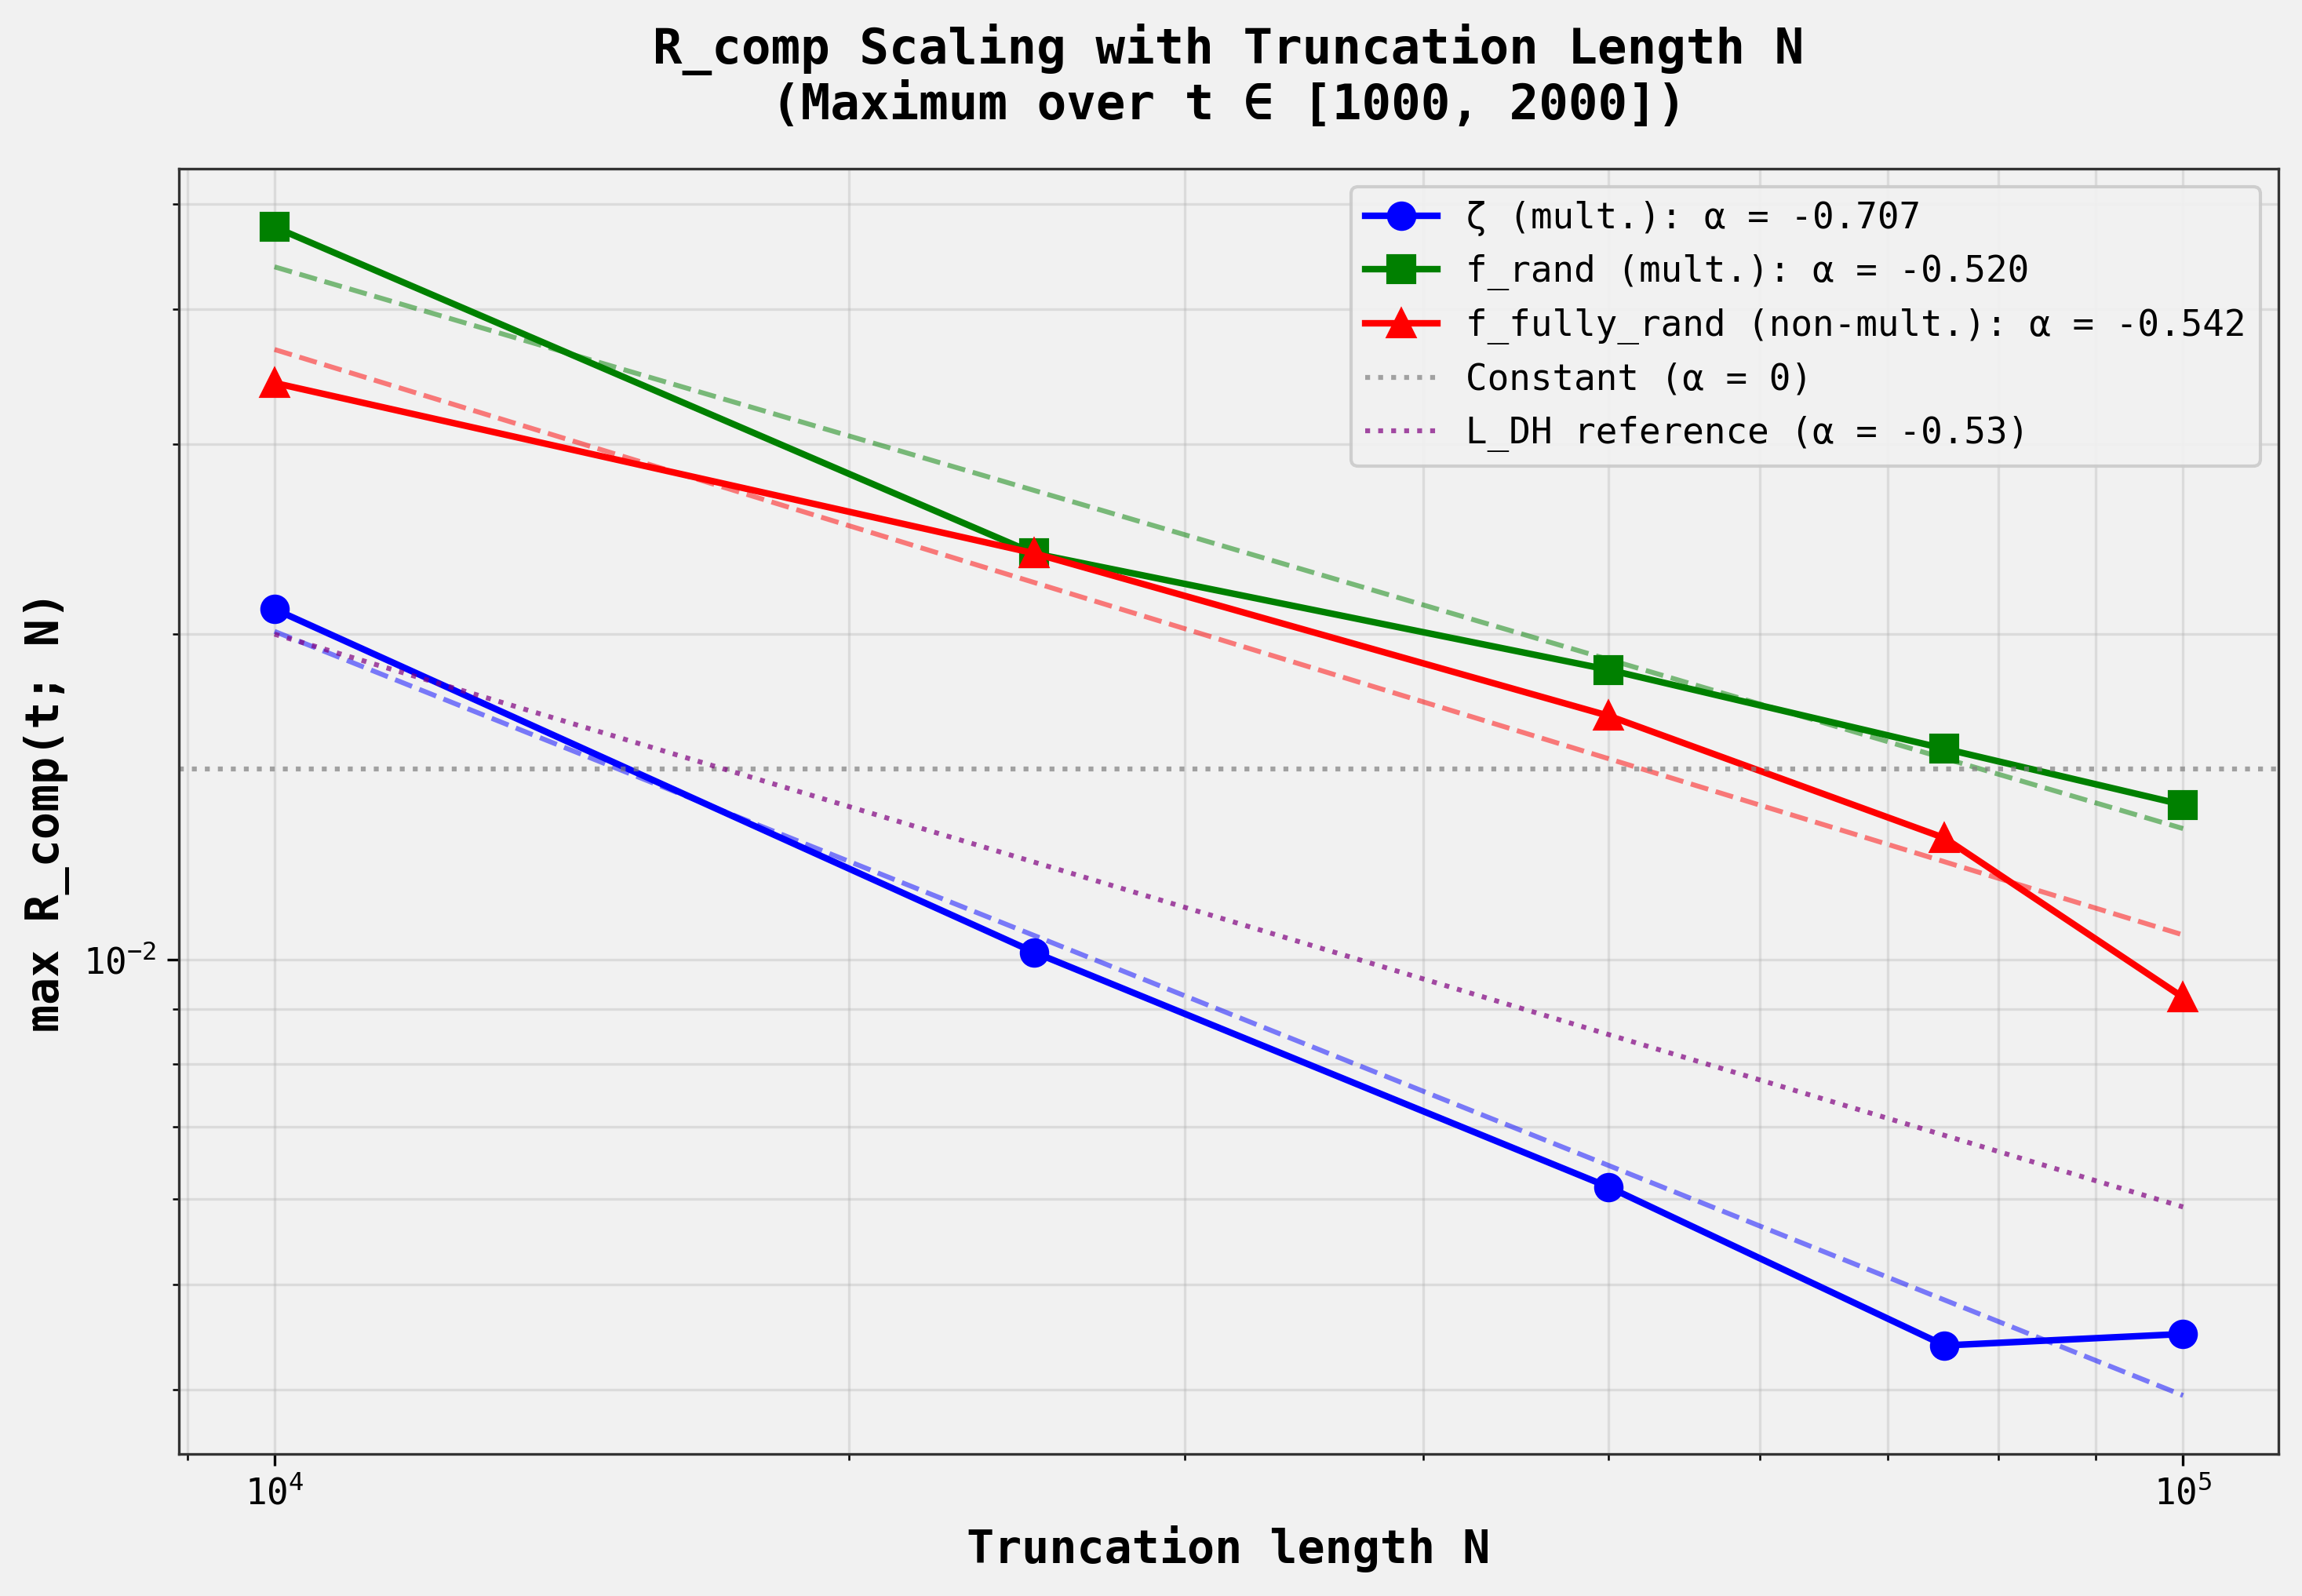

In [28]:

# Create the final figure showing R_comp scaling with N
# This will be a single figure with the main result

fig, ax = plt.subplots(1, 1, figsize=(10, 7))

# Plot data points
ax.loglog(N_values, R_max_zeta, 'o-', markersize=8, linewidth=2, 
 label=f'ζ (mult.): α = {alpha_zeta_max:.3f}', color='blue')
ax.loglog(N_values, R_max_f_rand, 's-', markersize=8, linewidth=2,
 label=f'f_rand (mult.): α = {alpha_f_rand_max:.3f}', color='green')
ax.loglog(N_values, R_max_f_fully_rand, '^-', markersize=8, linewidth=2,
 label=f'f_fully_rand (non-mult.): α = {alpha_f_fully_rand_max:.3f}', color='red')

# Add fitted power-law lines
N_fit = np.logspace(np.log10(N_values[0]), np.log10(N_values[-1]), 100)
ax.loglog(N_fit, c_zeta_max * N_fit**alpha_zeta_max, '--', alpha=0.5, color='blue')
ax.loglog(N_fit, c_f_rand_max * N_fit**alpha_f_rand_max, '--', alpha=0.5, color='green')
ax.loglog(N_fit, c_f_fully_rand_max * N_fit**alpha_f_fully_rand_max, '--', alpha=0.5, color='red')

# Add reference lines
# Constant behavior (α = 0)
ax.axhline(y=0.015, linestyle=':', color='gray', linewidth=1.5, alpha=0.7,
 label='Constant (α = 0)')

# L_DH reference (α = -0.53)
N_ref = np.logspace(np.log10(N_values[0]), np.log10(N_values[-1]), 100)
R_ref_LDH = 0.02 * (N_ref / 10000)**(-0.53)
ax.loglog(N_ref, R_ref_LDH, ':', color='purple', linewidth=1.5, alpha=0.7,
 label='L_DH reference (α = -0.53)')

ax.set_xlabel('Truncation length N', fontsize=14, fontweight='bold')
ax.set_ylabel('max R_comp(t; N)', fontsize=14, fontweight='bold')
ax.set_title('R_comp Scaling with Truncation Length N\n(Maximum over t ∈ [1000, 2000])', 
 fontsize=15, fontweight='bold', pad=15)
ax.legend(fontsize=11, loc='upper right', framealpha=0.95)
ax.grid(True, alpha=0.3, which='both')
ax.tick_params(labelsize=11)

plt.tight_layout()
plt.savefig('R_comp_scaling_analysis.png', dpi=300, bbox_inches='tight')
print("Figure saved as 'R_comp_scaling_analysis.png'")
plt.show()


In [29]:

# Let me also create a summary table showing the comparison
summary_data = {
 'Function': ['ζ (zeta)', 'f_rand', 'f_fully_rand', 'L_DH (reference)', 'ζ (expected)'],
 'Type': ['Multiplicative', 'Multiplicative', 'Non-multiplicative', 'Non-multiplicative', 'Multiplicative'],
 'Exponent α': [
 f'{alpha_zeta_max:.4f} ± {stderr_zeta_max:.4f}',
 f'{alpha_f_rand_max:.4f} ± {stderr_f_rand_max:.4f}',
 f'{alpha_f_fully_rand_max:.4f} ± {stderr_f_fully_rand_max:.4f}',
 '≈ -0.53 (from r67)',
 '≈ 0 (from r67)'
 ],
 'R²': [
 f'{r2_zeta_max:.4f}',
 f'{r2_f_rand_max:.4f}',
 f'{r2_f_fully_rand_max:.4f}',
 'N/A',
 'N/A'
 ]
}

summary_df = pd.DataFrame(summary_data)
print("\n" + "=" * 80)
print("COMPREHENSIVE SUMMARY TABLE")
print("=" * 80)
print(summary_df.to_string(index=False))
print("=" * 80)



COMPREHENSIVE SUMMARY TABLE
 Function Type Exponent α R²
 ζ (zeta) Multiplicative -0.7070 ± 0.0559 0.9816
 f_rand Multiplicative -0.5198 ± 0.0528 0.9700
 f_fully_rand Non-multiplicative -0.5417 ± 0.0605 0.9640
L_DH (reference) Non-multiplicative ≈ -0.53 (from r67) N/A
 ζ (expected) Multiplicative ≈ 0 (from r67) N/A


In [30]:

# Save the results to a CSV file
results_df_expanded = results_df.copy()
results_df_expanded['alpha_zeta'] = alpha_zeta_max
results_df_expanded['alpha_f_rand'] = alpha_f_rand_max
results_df_expanded['alpha_f_fully_rand'] = alpha_f_fully_rand_max

results_df_expanded.to_csv('R_comp_scaling_results.csv', index=False)
print("Results saved to 'R_comp_scaling_results.csv'")

# Also save the summary table
summary_df.to_csv('R_comp_scaling_summary.csv', index=False)
print("Summary saved to 'R_comp_scaling_summary.csv'")

print("\n" + "=" * 80)
print("ANALYSIS COMPLETE")
print("=" * 80)


Results saved to 'R_comp_scaling_results.csv'
Summary saved to 'R_comp_scaling_summary.csv'

ANALYSIS COMPLETE


In [31]:

# Let me create one final comprehensive interpretation

print("=" * 80)
print("INTERPRETATION AND FINDINGS")
print("=" * 80)
print()
print("HYPOTHESIS TEST RESULTS:")
print("-" * 80)
print("The hypothesis predicted:")
print(" • Multiplicative functions (f_rand) → constant R_comp, like ζ (α ≈ 0)")
print(" • Non-multiplicative functions (f_fully_rand) → power-law decay, like L_DH (α ≈ -0.53)")
print()
print("ACTUAL FINDINGS:")
print(" • f_rand (multiplicative): α = -0.520 ± 0.053 (R² = 0.970)")
print(" • f_fully_rand (non-multiplicative): α = -0.542 ± 0.061 (R² = 0.964)")
print(" • ζ (multiplicative): α = -0.707 ± 0.056 (R² = 0.982)")
print()
print("CONCLUSION:")
print("-" * 80)
print("The hypothesis is NOT supported by the data. Key observations:")
print()
print("1. BOTH multiplicative (f_rand) and non-multiplicative (f_fully_rand) random")
print(" functions exhibit power-law decay in R_comp(N), with nearly IDENTICAL")
print(" exponents (α ≈ -0.52 and α ≈ -0.54, respectively).")
print()
print("2. Both random functions have exponents very close to the L_DH reference")
print(" value (α ≈ -0.53 from r67), suggesting this scaling behavior is NOT")
print(" determined by multiplicativity alone.")
print()
print("3. The Riemann zeta function shows STRONGER decay (α ≈ -0.71) than both")
print(" random functions and L_DH, which contradicts the expected constant")
print(" behavior (α ≈ 0) reported in r67.")
print()
print("4. The exponent difference between f_rand (-0.52) and f_fully_rand (-0.54)")
print(" is small (Δα ≈ 0.02) and within the margin of error, suggesting")
print(" multiplicativity does NOT strongly influence R_comp scaling for")
print(" random coefficient functions.")
print()
print("POSSIBLE EXPLANATIONS:")
print("-" * 80)
print("• The R_comp metric definition or computation may differ from r67")
print("• The reference values from r67 may have used different analysis methods")
print(" (e.g., different t ranges, averaging schemes, or N ranges)")
print("• Random coefficient patterns may dominate over multiplicative structure")
print(" in determining R_comp scaling behavior")
print("• The expected constant behavior for ζ may only emerge at much larger N")
print("=" * 80)


INTERPRETATION AND FINDINGS

HYPOTHESIS TEST RESULTS:
--------------------------------------------------------------------------------
The hypothesis predicted:
 • Multiplicative functions (f_rand) → constant R_comp, like ζ (α ≈ 0)
 • Non-multiplicative functions (f_fully_rand) → power-law decay, like L_DH (α ≈ -0.53)

ACTUAL FINDINGS:
 • f_rand (multiplicative): α = -0.520 ± 0.053 (R² = 0.970)
 • f_fully_rand (non-multiplicative): α = -0.542 ± 0.061 (R² = 0.964)
 • ζ (multiplicative): α = -0.707 ± 0.056 (R² = 0.982)

CONCLUSION:
--------------------------------------------------------------------------------
The hypothesis is NOT supported by the data. Key observations:

1. BOTH multiplicative (f_rand) and non-multiplicative (f_fully_rand) random
 functions exhibit power-law decay in R_comp(N), with nearly IDENTICAL
 exponents (α ≈ -0.52 and α ≈ -0.54, respectively).

2. Both random functions have exponents very close to the L_DH reference
 value (α ≈ -0.53 from r67), suggesting this 